# uGMRT Preprocess Workflow (Production)

This notebook is a thin workflow wrapper around module functions in `ugmrt_query.py`.

Core loop:
1. Derive bandpass
2. Run diagnostics
3. Propose/write flag table updates
4. Repeat from Step 1 with one or more flag tables

All operations are non-destructive: input visibilities are never modified on disk.

In [ ]:
import importlib
import sys
from pathlib import Path

if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])
import ugmrt_query as q

print('ugmrt_query loaded')

In [ ]:
# User configuration
ITER_TAG = 'iter03'

BASE_DIR = Path('/media/wasim/gmrt_40_014')
WORK_DIR = BASE_DIR / 'work'

CAL_FITS = WORK_DIR / '40_014_25JUL2021_copy' / '40_014_25jul2021_gsb.FITS'
INDEX_CACHE = WORK_DIR / '40_014_25jul2021_gsb.row_index_cache.npz'

# Row-index cache validation mode:
#   'fast'      -> compare file size + modification time
#   'fast+sha'  -> fast check first; on mismatch, verify SHA before rebuild
#   'sha256'    -> compare full SHA256 hash every run (strict, slower)
#   'none'      -> trust cache without checking source file
INDEX_VALIDATION_MODE = 'fast+sha'

# Multiple on-disk flag tables can be merged on-the-fly
FLAG_TABLE_BASE = WORK_DIR / '3c48_flag_table.json'
FLAG_TABLE_SESSION = WORK_DIR / '3c48_flag_table_session.json'
FLAG_TABLE_PATHS = [p for p in [FLAG_TABLE_BASE, FLAG_TABLE_SESSION] if p.exists()]

# In-memory flag tables proposed in earlier dry-run iterations can also be reused on-the-fly.
if 'PENDING_FLAG_TABLES' not in globals():
    PENDING_FLAG_TABLES = []

# User control: set USE_PENDING_FLAG_TABLES=False if you do not want dry-run proposals
# from previous iterations to affect the next bandpass solve.
USE_PENDING_FLAG_TABLES = True

# Optional reset switch: set CLEAR_PENDING_FLAG_TABLES=True once to discard any previously
# carried in-memory proposals, then run this cell.
CLEAR_PENDING_FLAG_TABLES = False
if CLEAR_PENDING_FLAG_TABLES:
    PENDING_FLAG_TABLES = []

DRY_RUN_BANDPASS = True
DRY_RUN_FLAG_WRITE = True

# Solve options
SOURCE = '3C48'
STOKES = ('RR', 'LL')
CHAN_RANGE = (64, 191)
MAX_ROWS_SOLVE = 150_000
SMOOTH_WINDOW = 5
MIN_BASELINES = 20
COUPLE_STOKES_FLAGS = True

# Diagnostics options
EXCLUDE_FOR_PLOTS = []
SKIP_EDGE_CHANNELS = (0, 0)
TOP_N = 12
DIAG_APPLY_FLAGS_ON_THE_FLY = True
DIAG_SAVE_UNFLAGGED_COMPARISON = False

print('CAL_FITS:', CAL_FITS)
print('INDEX_CACHE:', INDEX_CACHE)
print('INDEX_VALIDATION_MODE:', INDEX_VALIDATION_MODE)
print('FLAG_TABLE_PATHS:', FLAG_TABLE_PATHS)
print('Pending in-memory flag tables available:', len(PENDING_FLAG_TABLES))
print('USE_PENDING_FLAG_TABLES:', USE_PENDING_FLAG_TABLES)
print('CLEAR_PENDING_FLAG_TABLES:', CLEAR_PENDING_FLAG_TABLES)
print('ITER_TAG:', ITER_TAG)
print('DRY_RUN_BANDPASS:', DRY_RUN_BANDPASS)
print('DRY_RUN_FLAG_WRITE:', DRY_RUN_FLAG_WRITE)
print('COUPLE_STOKES_FLAGS:', COUPLE_STOKES_FLAGS)
print('DIAG_APPLY_FLAGS_ON_THE_FLY:', DIAG_APPLY_FLAGS_ON_THE_FLY)
print('DIAG_SAVE_UNFLAGGED_COMPARISON:', DIAG_SAVE_UNFLAGGED_COMPARISON)

In [ ]:
# Step 1: Load or build persistent row index cache
row_index = q.get_or_build_row_index(
    CAL_FITS,
    cache_path=INDEX_CACHE,
    force_rebuild=False,
    validation_mode=INDEX_VALIDATION_MODE,
    write_cache=True,
 )

print('Index path:', row_index.get('index_cache_path', INDEX_CACHE))
print('Source identity:', row_index.get('source_identity'))
print('Source SHA256:', row_index.get('source_sha256'))

In [ ]:
# Step 2: Derive bandpass (non-destructive)
BANDPASS_OUT_BASE = WORK_DIR / '3c48_bandpass_25jul_gsb.npz'
active_pending_flag_tables = PENDING_FLAG_TABLES if USE_PENDING_FLAG_TABLES else []

bandpass_run = q.derive_bandpass_iteration(
    fits_path=CAL_FITS,
    index=row_index,
    bandpass_out=BANDPASS_OUT_BASE,
    source=SOURCE,
    stokes=STOKES,
    chan_range=CHAN_RANGE,
    max_rows=MAX_ROWS_SOLVE,
    smooth_window=SMOOTH_WINDOW,
    min_baselines=MIN_BASELINES,
    ignore_autos=True,
    flag_table_path=FLAG_TABLE_PATHS if FLAG_TABLE_PATHS else None,
    flag_table=active_pending_flag_tables if active_pending_flag_tables else None,
    couple_stokes_flags=COUPLE_STOKES_FLAGS,
    iteration_tag=ITER_TAG,
    dry_run=DRY_RUN_BANDPASS,
 )

bandpass_sol = bandpass_run['solution']
bandpass_out_path = bandpass_run['bandpass_out']

print('Bandpass dry-run:', bandpass_run['dry_run'])
print('Bandpass output path:', bandpass_out_path)
print('On-disk flag tables used:', FLAG_TABLE_PATHS)
print('Pending in-memory flag tables available:', len(PENDING_FLAG_TABLES))
print('Pending in-memory flag tables applied:', len(active_pending_flag_tables))
print('Merged flag tables seen by solve:', bandpass_sol.get('flag_table_paths', []))
print('Merged flag table count:', bandpass_sol.get('flag_table_count', 0))
print('Rows dropped by merged flags:', bandpass_sol.get('solve_dropped_rows_by_flag_table', 0))

In [ ]:
proposal = q.propose_flag_updates_from_diagnostics(
    diag,
    pol='LL',
    mode='both',
    antenna_flag_threshold_jy=180.0,
    baseline_flag_threshold_jy=800.0,
    max_antennas_to_flag=1,
    max_baselines_to_flag=6,
 )

print('Candidate antennas:', proposal['candidate_antennas'])
print('Candidate baselines:', proposal['candidate_baselines'])


Loaded row index cache: /media/wasim/gmrt_40_014/work/40_014_25jul2021_gsb.row_index_cache.npz
[load_vis] 57,456 rows, 353 MB read, 16.9s
[bandpass-solve] merged flag tables applied: dropped 3,496 rows, kept 53,960 rows; excluded antennas=[], excluded baselines=23; tables=1
[load_vis] 57,456 rows, 353 MB read, 13.0s
[bandpass-diagnostics] merged flag tables applied: dropped 3,496 rows, kept 53,960 rows; excluded antennas=[], excluded baselines=23; tables=1


/media/wasim/gmrt_40_014/ugmrt_query.py:1956: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.97))


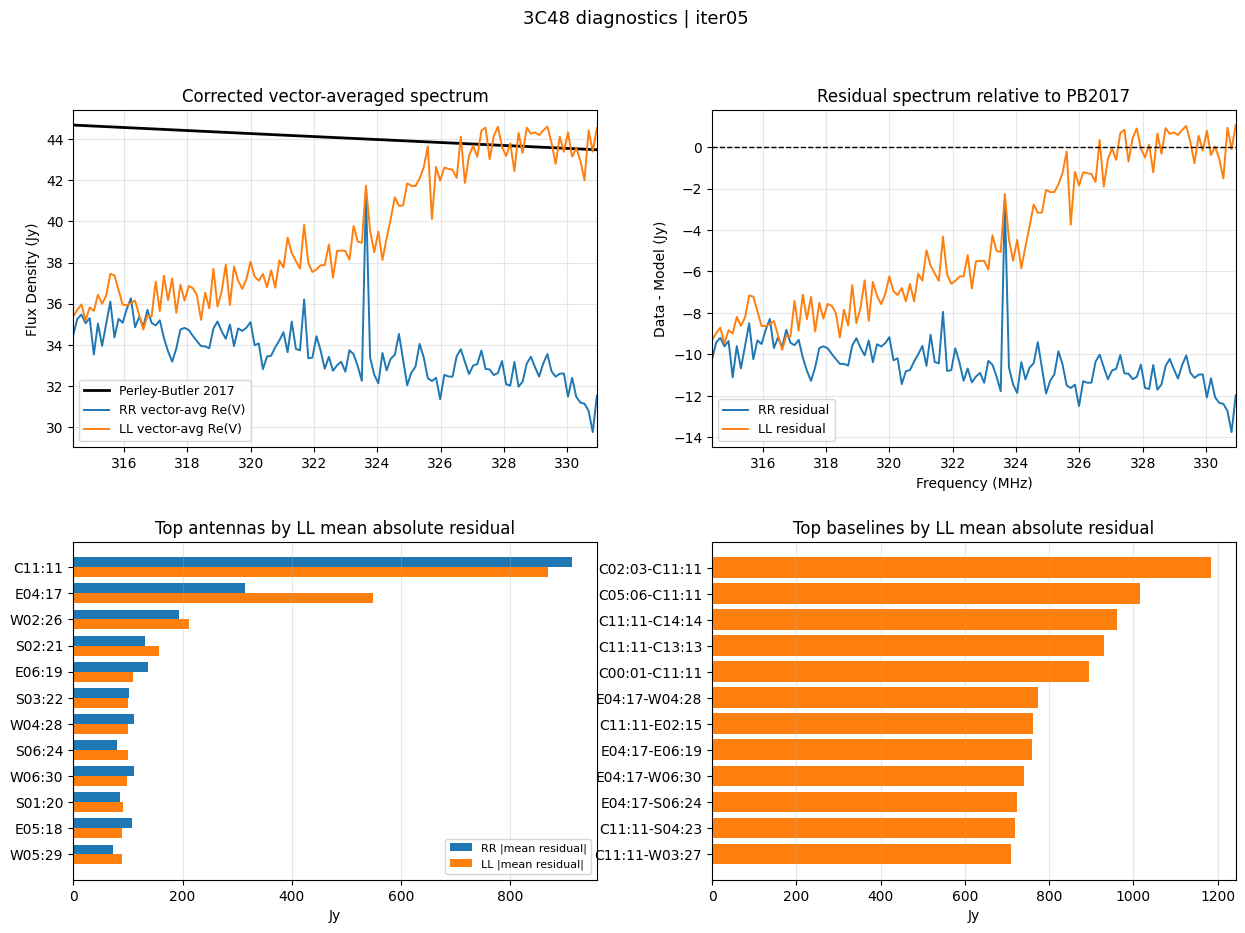

[load_vis] 57,456 rows, 353 MB read, 13.7s
[bandpass-solve] merged flag tables applied: dropped 4,256 rows, kept 53,200 rows; excluded antennas=[], excluded baselines=28; tables=1
[load_vis] 57,456 rows, 353 MB read, 8.6s
[bandpass-diagnostics] merged flag tables applied: dropped 4,256 rows, kept 53,200 rows; excluded antennas=[], excluded baselines=28; tables=1


/media/wasim/gmrt_40_014/ugmrt_query.py:1956: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.97))


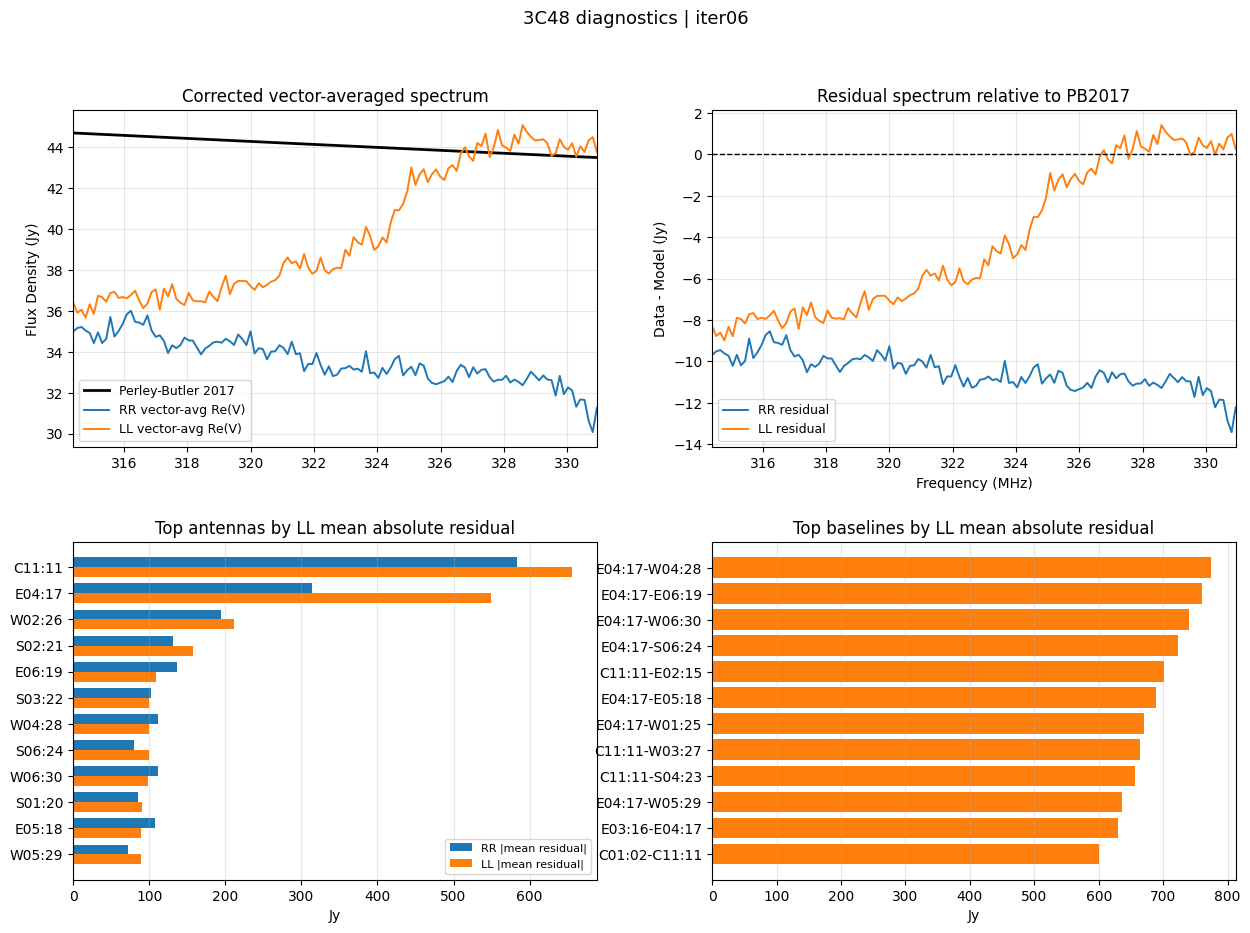

[load_vis] 57,456 rows, 353 MB read, 16.7s
[bandpass-solve] merged flag tables applied: dropped 4,256 rows, kept 53,200 rows; excluded antennas=[], excluded baselines=28; tables=1
[load_vis] 57,456 rows, 353 MB read, 13.8s
[bandpass-diagnostics] merged flag tables applied: dropped 4,256 rows, kept 53,200 rows; excluded antennas=[], excluded baselines=28; tables=1


/media/wasim/gmrt_40_014/ugmrt_query.py:1956: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.97))


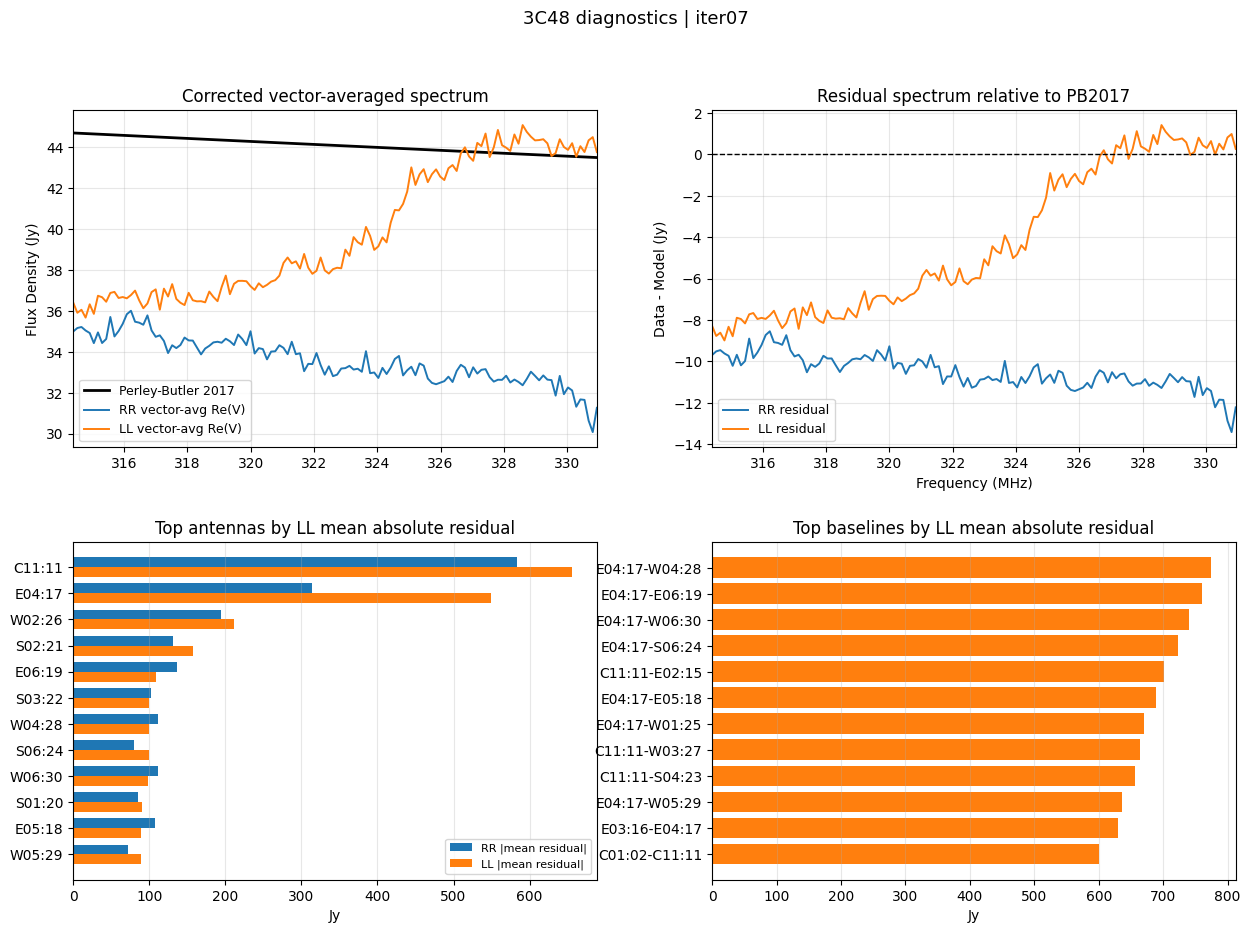

[load_vis] 57,456 rows, 353 MB read, 19.8s
[bandpass-solve] merged flag tables applied: dropped 4,256 rows, kept 53,200 rows; excluded antennas=[], excluded baselines=28; tables=1
[load_vis] 57,456 rows, 353 MB read, 20.7s
[bandpass-diagnostics] merged flag tables applied: dropped 4,256 rows, kept 53,200 rows; excluded antennas=[], excluded baselines=28; tables=1


/media/wasim/gmrt_40_014/ugmrt_query.py:1956: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.97))


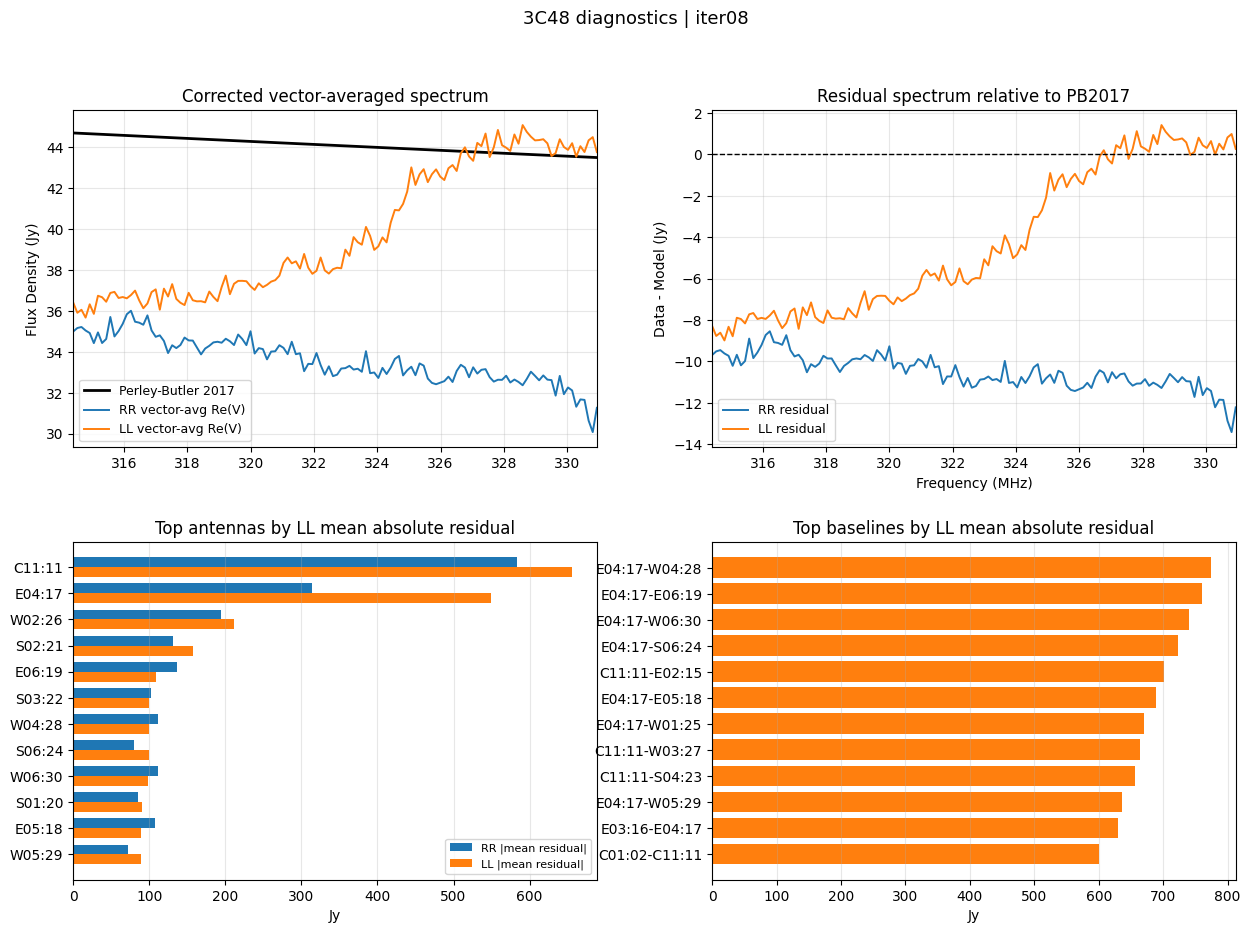

Auto iterations executed: 4
AUTO_ITERATION_WIDTH: 2 -> tags like iter05
iter05: cand_base=5, cum_base=28, diag_drop=3496, plot=/media/wasim/gmrt_40_014/work/3c48_bandpass_diagnostics_iter05.png
iter06: cand_base=0, cum_base=28, diag_drop=4256, plot=/media/wasim/gmrt_40_014/work/3c48_bandpass_diagnostics_iter06.png
iter07: cand_base=0, cum_base=28, diag_drop=4256, plot=/media/wasim/gmrt_40_014/work/3c48_bandpass_diagnostics_iter07.png
iter08: cand_base=0, cum_base=28, diag_drop=4256, plot=/media/wasim/gmrt_40_014/work/3c48_bandpass_diagnostics_iter08.png
Pending in-memory flag tables now: 1


In [ ]:
    proposal_pol='LL',
    proposal_mode='both',
    antenna_flag_threshold_jy=180.0,
    baseline_flag_threshold_jy=800.0,
    max_antennas_to_flag=1,
    max_baselines_to_flag=6,


## Iteration Loop
For the next iteration:
1. Set `ITER_TAG` to the next value (for example `iter02`).
2. If you want outputs written, set `DRY_RUN_BANDPASS=False` and `DRY_RUN_FLAG_WRITE=False`.
3. Re-run cells 4 to 6.
4. On-disk flag tables are always taken from `FLAG_TABLE_PATHS`.
5. Dry-run proposals are kept in memory as `PENDING_FLAG_TABLES`, but they are only applied if `USE_PENDING_FLAG_TABLES=True`.
6. If you want to stop propagation completely, set `USE_PENDING_FLAG_TABLES=False`.
7. If you want to discard already-carried in-memory proposals, set `CLEAR_PENDING_FLAG_TABLES=True` once and rerun the configuration cell.
8. Set `DIAG_APPLY_FLAGS_ON_THE_FLY=True` to apply merged flag tables before diagnostics statistics.
9. Set `DIAG_SAVE_UNFLAGGED_COMPARISON=True` to save an additional unflagged diagnostic plot for side-by-side comparison.
10. The automation cell is self-contained and can run without first executing the manual config/index cells.
11. `AUTO_ITERATION_WIDTH` controls zero-padding of iteration tags: width `2` gives `iter01`, width `3` gives `iter001`.

All filtering and calibration are performed in memory; raw vis data on disk remains untouched.